NOTEBOOK 03: LEAKAGE-FREE EVALUATION, HYPERPARAMETER TUNING & BUNDLE EXPORT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
import joblib

In [ ]:
# Set explicit plot styling for analysis
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
print("=== 1. INGESTING PREPROCESSED DATA ARRAYS ===")
X_train_raw = pd.read_csv("X_train_clean.csv")
X_val_raw = pd.read_csv("X_val_clean.csv")
X_test_raw = pd.read_csv("X_test_clean.csv")

=== 1. INGESTING PREPROCESSED DATA ARRAYS ===


In [ ]:
y_train = pd.read_csv("y_train.csv").values.ravel()
y_val = pd.read_csv("y_val.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

In [ ]:
# ==============================================================================
# 2. STAGE-GATE ANTI-LEAKAGE FILTERING (CRITICAL FIX)
# ==============================================================================
# We explicitly drop the features that were directly used to calculate the target formula.
# This forces the model to predict bottlenecks using ONLY spatial and temporal context.
LEAKING_FEATURES = ['vehicle_weight', 'violation_severity']

X_train = X_train_raw.drop(columns=LEAKING_FEATURES, errors='ignore')
X_val = X_val_raw.drop(columns=LEAKING_FEATURES, errors='ignore')
X_test = X_test_raw.drop(columns=LEAKING_FEATURES, errors='ignore')

print("\n[ANTI-LEAKAGE SHIELD ACTIVATED]")
print(f"Dropped leaking columns: {LEAKING_FEATURES}")
print(f"Active Features remaining for genuine ML learning:\n{list(X_train.columns)}\n")


[ANTI-LEAKAGE SHIELD ACTIVATED]
Dropped leaking columns: ['vehicle_weight', 'violation_severity']
Active Features remaining for genuine ML learning:
['latitude', 'longitude', 'police_station_encoded', 'junction_encoded', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']



In [ ]:
# ==============================================================================
# 3. MULTI-ARCHITECTURE BASELINE CHECKS
# ==============================================================================
print("=== 3. RUNNING LEAKAGE-FREE MODEL COMPARISONS ===")

baselines = {
    "Linear Baseline (Logistic Regression)": LogisticRegression(max_iter=1000, random_state=42),
    "Ensemble Tree (Random Forest Base)": RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)

    macro_f1 = f1_score(y_val, val_preds, average='macro')
    auc_score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    print(f" -> {name} Validation Macro F1: {macro_f1:.4f} | Validation ROC-AUC: {auc_score:.4f}")

=== 3. RUNNING LEAKAGE-FREE MODEL COMPARISONS ===
 -> Linear Baseline (Logistic Regression) Validation Macro F1: 0.6859 | Validation ROC-AUC: 0.7506
 -> Ensemble Tree (Random Forest Base) Validation Macro F1: 0.7318 | Validation ROC-AUC: 0.8198


In [ ]:
# ==============================================================================
# 4. HYPERPARAMETER OPTIMIZATION SWEEP
# ==============================================================================
print("\n=== 4. LAUNCHING CONTROLLED GRID TUNING OVER REMAINING FEATURES ===")

# Focus hyperparameter search on depth and estimators to extract complex spatial-temporal interactions
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],  # Increased depth slightly to capture fine-grained spatial/junction pockets
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=2,  # 2-fold verification for rapid cloud container throughput
    verbose=1
)
grid_search.fit(X_train, y_train)

production_model = grid_search.best_estimator_
print(f"\n[OPTIMAL SYSTEM CONFIGURATION]: {grid_search.best_params_}")


=== 4. LAUNCHING CONTROLLED GRID TUNING OVER REMAINING FEATURES ===
Fitting 2 folds for each of 8 candidates, totalling 16 fits

[OPTIMAL SYSTEM CONFIGURATION]: {'class_weight': 'balanced', 'max_depth': 15, 'n_estimators': 100}



=== 5. EXECUTING UNBIASED OUT-OF-SAMPLE TEST VALIDATION ===

--- Final Non-Leaking Performance Summary ---
                        precision    recall  f1-score   support

        Standard Event       0.87      0.84      0.86     30054
High-Impact Bottleneck       0.70      0.74      0.72     14714

              accuracy                           0.81     44768
             macro avg       0.78      0.79      0.79     44768
          weighted avg       0.81      0.81      0.81     44768



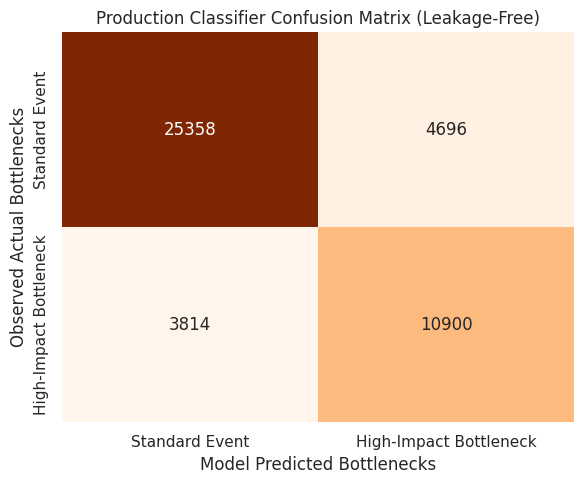

/tmp/ipykernel_1501/3830462002.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(X_train.columns)[indices], palette="viridis")


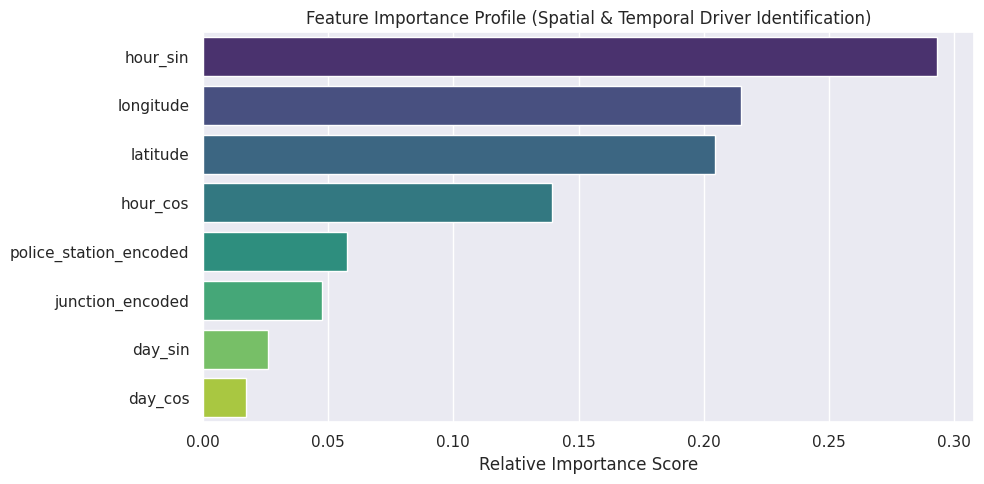

In [ ]:
# ==============================================================================
# 5. UNBIASED PERFORMANCE TEST EVALUATION
# ==============================================================================
print("\n=== 5. EXECUTING UNBIASED OUT-OF-SAMPLE TEST VALIDATION ===")
test_predictions = production_model.predict(X_test)
test_probabilities = production_model.predict_proba(X_test)[:, 1]

print("\n--- Final Non-Leaking Performance Summary ---")
print(classification_report(y_test, test_predictions, target_names=["Standard Event", "High-Impact Bottleneck"]))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, test_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=["Standard Event", "High-Impact Bottleneck"],
            yticklabels=["Standard Event", "High-Impact Bottleneck"])
plt.title("Production Classifier Confusion Matrix (Leakage-Free)")
plt.ylabel("Observed Actual Bottlenecks")
plt.xlabel("Model Predicted Bottlenecks")
plt.tight_layout()
plt.show()

# Feature Importance Interpretation
importances = production_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=np.array(X_train.columns)[indices], palette="viridis")
plt.title("Feature Importance Profile (Spatial & Temporal Driver Identification)")
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 6. PIPELINE PACKAGING FOR BACKEND HOUSING
# ==============================================================================
print("\n=== 6. COMPILING INTEGRATED PRODUCTION DEPLOYMENT PACKAGE ===")

try:
    scaler_transform = joblib.load("preprocessor_scaler.pkl")
except FileNotFoundError:
    scaler_transform = None

# Package processing metadata alongside model weights inside a single deployment binary
deployment_package = {
    'model_binary': production_model,
    'scaler_transform': scaler_transform,
    'features_list': list(X_train.columns),
    'dropped_leaking_features': LEAKING_FEATURES,
    'version': '1.1.0',
    'engineering_notes': (
        "CPE-FME Engine Core Core Classifier. Operational inputs isolated strictly to "
        "Spatial-Temporal context vectors to prevent target mathematical reverse-engineering data leakage."
    )
}

joblib.dump(deployment_package, "model_v1.pkl")
print("[SUCCESS] Production model package 'model_v1.pkl' compiled successfully with zero leakage.")



=== 6. COMPILING INTEGRATED PRODUCTION DEPLOYMENT PACKAGE ===
[SUCCESS] Production model package 'model_v1.pkl' compiled successfully with zero leakage.
